# 排序

In [1]:
import numpy as np
a = np.array([8,7,9,4,6,0])
N = len(a)

print(a)


[8 7 9 4 6 0]


In [2]:
for i in range(1,N):
    temp = a[i]
    j = i-1
    while (j>=0 and temp < a[j]):
        a[j+1] = a[j]
        j = j-1
    a[j+1] = temp

print(a)

[0 4 6 7 8 9]


In [3]:
def shell_sort(a):
    n = len(a)
    gap = n // 2
    while gap > 0:
        for i in range(gap, n):
            tmp = a[i]
            j = i
            while j >= gap and a[j - gap] > tmp:
                a[j] = a[j - gap]
                j -= gap
            a[j] = tmp
        gap //= 2
    return a

In [4]:
x = np.array([8,7,9,4,6,0,6,8,9,25,32])
shell_sort(x)

array([ 0,  4,  6,  6,  7,  8,  8,  9,  9, 25, 32])

In [13]:
def quick_sort(a):
    a = a.tolist() if hasattr(a, "tolist") else list(a)  # 兼容 numpy array / list
    if len(a) <= 1:
        return a
    pivot = a[len(a) // 2]
    left  = [x for x in a if x < pivot]
    mid   = [x for x in a if x == pivot]
    right = [x for x in a if x > pivot]
    return quick_sort(left) + mid + quick_sort(right)

In [15]:
x = np.array([8,7,9,4,6,0,6,8,9.1,25,32])
quick_sort(x)

[0.0, 4.0, 6.0, 6.0, 7.0, 8.0, 8.0, 9.0, 9.1, 25.0, 32.0]

In [18]:
def counting_sort(a):
    a = a.tolist() if hasattr(a, "tolist") else list(a)  # 兼容 numpy array / list
    a = list(a)
    if not a:
        return a
    mn, mx = min(a), max(a)
    cnt = [0] * (mx - mn + 1)
    for x in a:
        cnt[x - mn] += 1
    out = []
    for i, c in enumerate(cnt):
        out.extend([i + mn] * c)
    return out

In [19]:
x = np.array([8,7,9,4,6,0,6,8,9,25,32])
counting_sort(x)

[0, 4, 6, 6, 7, 8, 8, 9, 9, 25, 32]

# 插值

In [20]:
import numpy as np

def richardson(Ah, Ah2, p):
    return (2**p * Ah2 - Ah) / (2**p - 1)

def d_central(f, x, h):
    return (f(x + h) - f(x - h)) / (2*h)

# 例子：求 f(x)=sin(x) 在 x=1 处的导数（真值是 cos(1)）
f = np.sin
x = 1.0
h = 0.1

D_h   = d_central(f, x, h)      # O(h^2)
D_h2  = d_central(f, x, h/2)    # O((h/2)^2)
D_ext = richardson(D_h, D_h2, p=2)  # 外推到更高精度

print("D(h)      =", D_h)
print("D(h/2)    =", D_h2)
print("Richardson=", D_ext)
print("Exact     =", np.cos(x))

D(h)      = 0.53940225216976
D(h/2)    = 0.5400772080464322
Richardson= 0.5403021933386563
Exact     = 0.5403023058681398


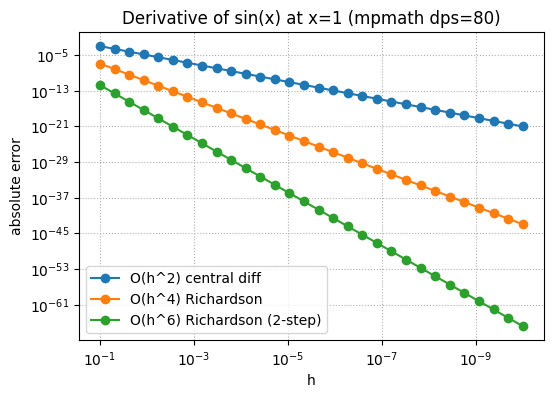

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

mp.mp.dps = 80  # 小数位精度，按需调大

def d_central_mp(f, x, h):
    return (f(x + h) - f(x - h)) / (2*h)

def richardson_mp(Ah, Ah2, p):
    return (mp.power(2, p) * Ah2 - Ah) / (mp.power(2, p) - 1)

# 误差随步长 h 的变化：2阶中心差分、4阶 Richardson、再外推到 6阶（用 mpmath 高精度计算）
f = mp.sin
x0 = mp.mpf("1")
exact = mp.cos(x0)

# mpmath 没有 logspace：先用 numpy 生成，再转成 mp.mpf
hs_f = np.logspace(-1, -10, 30)  # float64，用于画图
hs = [mp.mpf(str(h)) for h in hs_f]

err_2 = []
err_4 = []
err_6 = []

for h in hs:
    D1 = d_central_mp(f, x0, h)        # O(h^2)
    D2 = d_central_mp(f, x0, h/2)      # O(h^2)
    D3 = d_central_mp(f, x0, h/4)      # O(h^2)

    R12 = richardson_mp(D1, D2, p=2)   # O(h^4)
    R23 = richardson_mp(D2, D3, p=2)   # O(h^4)
    R123 = richardson_mp(R12, R23, p=4)  # O(h^6)

    err_2.append(abs(D1 - exact))
    err_4.append(abs(R12 - exact))
    err_6.append(abs(R123 - exact))

# matplotlib 需要 float
err_2_f = [float(e) for e in err_2]
err_4_f = [float(e) for e in err_4]
err_6_f = [float(e) for e in err_6]

plt.figure(figsize=(6,4))
plt.loglog(hs_f, err_2_f, 'o-', label='O(h^2) central diff')
plt.loglog(hs_f, err_4_f, 'o-', label='O(h^4) Richardson')
plt.loglog(hs_f, err_6_f, 'o-', label='O(h^6) Richardson (2-step)')
plt.gca().invert_xaxis()  # h 从大到小更直观
plt.xlabel('h')
plt.ylabel('absolute error')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.title('Derivative of sin(x) at x=1 (mpmath dps=80)')
plt.show()

In [30]:
import mpmath as mp

mp.mp.dps = 80  # 小数位精度，按需调大

def d_central_mp(f, x, h):
    return (f(x + h) - f(x - h)) / (2*h)

def richardson_mp(Ah, Ah2, p):
    return (mp.power(2, p) * Ah2 - Ah) / (mp.power(2, p) - 1)

f = mp.sin
x0 = mp.mpf("1")
exact = mp.cos(x0)

h = mp.mpf("1e-5")
D1 = d_central_mp(f, x0, h)
D2 = d_central_mp(f, x0, h/2)
D3 = d_central_mp(f, x0, h/4)

R12 = richardson_mp(D1, D2, 2)     # O(h^4)
R23 = richardson_mp(D2, D3, 2)     # O(h^4)
R123 = richardson_mp(R12, R23, 4)  # O(h^6)

print("err2 =", abs(D1 - exact))
print("err4 =", abs(R12 - exact))
print("err6 =", abs(R123 - exact))

err2 = 0.0000000000090050384310906367645267056837713310967630073083972969342305910615221099535224878
err4 = 0.000000000000000000000011256298038886076558832300863361974571688812047697707519846547492302542722141336
err6 = 1.6750443510266455584155880945111529153217972982907862190225428946280481894093911e-36
